# Project 03: Gibbs Sampling (Random Algorithm)

`project03.ipynb`

This program implements a Gibbs Sampling algorithm to discover a short, shared DNA motif
across a list of sequences without knowing in advance where that motif falls
within each one. GibbsMotifFinder function builds an initial random guess for
each sequence, then repeatedly holds out one sequence at a time, builds a
consensus (a Position Frequency Matrix and Position Weight Matrix) from every
other sequence's current guess, scores every possible position in the held-out
sequence on both the forward and reverse-complement strands, and updates that
sequence's guess via weighted random selection favoring higher-scoring
positions, without ever being locked into always picking the single best
score. After a fixed number of rounds, a final consensus is built from every
sequence's last guess and returned as a Position Frequency Matrix.

For the Promotor Driver section, the function is tested on a
B. subtilis genome, pre-filtered down to sequences containing part of the
Shine-Dalgarno motif (AGGAGG), with each promoter sequence extracted using
get_seq from the 50 bp immediately upstream of each coding sequence (CDS)
identified from the accompanying GFF annotation file.

For the NRF1 Driver section, the same function is tested on a
second, larger dataset, real NRF1 ChIP-seq peak sequences (data/nrf1_gibbs.fa),
read in directly via get_fasta with no additional filtering, since every
sequence in that file is already a confirmed binding-site peak.

Authors 
1. Julianne Murthy
1. Graziano Peregrino
1. Ildiko Polyak.

In [42]:
import os
import shutil

```Add this section to be able to run the seqlogo```

In [30]:
import time

In [1]:
import random
import numpy as np
import seqlogo 
#import function for building sequence motif & idenfitying seqs matching to motif
from data_readers import *
from seq_ops import get_seq
from motif_ops import *

---
# Project Start

In [31]:
def GibbsMotifFinder (seqs, k, seed=None):
    '''
        Function to find a pfm from a list of strings using a Gibbs sampler
        
        Args: 
            seqs (str list): a list of sequences, not necessarily in same lengths
            k (int): the length of motif to find
            seed (int, default=None): seed for np.random
    
        Returns:
            pfm (numpy array): dimensions are 4xlength
        '''

    max_iter = 10000
    tolerance = 1e-6
    convergence_limit = 100

    random.seed(seed)
    rng = np.random.default_rng(seed)
    total_seqs = len(seqs) #N, total number of seqs

    start_time = time.time()
    # INITIALIZE random valid start position per sequence
    motifs = []
    for seq in seqs:
        start_pos = rng.integers(0, len(seq) - k + 1) #picks a start position at random
        motifs.append(seq[start_pos:start_pos + k]) # hold one k length chunk per seq
 
    # save the best scoring version of 4xk frequency matrix
    final_ic = -np.inf 
    final_pfm = build_pfm(motifs, k)
    stall_count = 0 # count how many iterations in a row that have failed improving
 
    for j in range(max_iter):
        # hold out one random sequence i
        i = rng.integers(0, total_seqs)
 
        # build pfm/pwm from all OTHER current motifs
        other_motifs = motifs[:i] + motifs[i + 1:]
        pfm_others = build_pfm(other_motifs, k) 
        pwm = build_pwm(pfm_others)

        # score every position in the held out sequence, both strands, keeping the better scoring chunk at each position
        seq_i = seqs[i]
        possible_pos = len(seq_i) - k + 1 # grabs all possible k-length start positions within the held out seq i

        best_scores = np.empty(possible_pos) #create numpy array of length possible_pos
        best_chunks = []
    
        for pos in range(possible_pos):
            forward_chunk = seq_i[pos:pos + k]
            reverse_chunk = reverse_complement(forward_chunk)
            forward_score = score_kmer(forward_chunk, pwm)
            reverse_score = score_kmer(reverse_chunk, pwm)
 
            if forward_score >= reverse_score:
                best_scores[pos] = forward_score
                best_chunks.append(forward_chunk)
            else:
                best_scores[pos] = reverse_score
                best_chunks.append(reverse_chunk)
 
        # undo log2, positive weights, normalize to probabilities
        weights = np.power(2.0, best_scores)
        probs = weights / weights.sum()

        # weighted random pick (NOT max), update motif i
        chosen_pos = rng.choice(possible_pos, p=probs)
        motifs[i] = best_chunks[chosen_pos]

        # convergence tracking
        full_pfm = build_pfm(motifs, k)    
        ic = pfm_ic(full_pfm)

        if ic > final_ic + tolerance:
            final_ic = ic
            final_pfm = full_pfm.copy()
            stall_count = 0
        else:
            stall_count += 1

        if (j + 1) % 500 == 0:
            elapsed_seconds = time.time() - start_time
            elapsed_minutes = elapsed_seconds / 60

            avg_time_per_iteration = elapsed_seconds / (j + 1)
            remaining_iterations = max_iter - (j + 1)

            estimated_remaining_seconds = (
                avg_time_per_iteration * remaining_iterations
            )

            estimated_remaining_minutes = (
                estimated_remaining_seconds / 60
            )

            print(f"--- Iteration {j + 1:,} / {max_iter:,} ---")
            print(f"Held-out sequence: {i}")
            print(f"Chosen position: {chosen_pos}")
            print(f"Current motif: {motifs[i]}")
            print(f"Current IC: {ic:.4f}")
            print(f"Best IC: {final_ic:.4f}")
            print(f"Elapsed time: {elapsed_minutes:.2f} minutes")
            print(
                f"Estimated remaining time: "
                f"{estimated_remaining_minutes:.2f} minutes"
            )
            print()

        # Stop if IC has not improved
        if stall_count >= convergence_limit:

            elapsed_minutes = (time.time() - start_time) / 60

            print(f"Converged at iteration {j + 1:,}")
            print(
                f"IC remained stable for "
                f"{convergence_limit} iterations."
            )
            print(f"Final elapsed time: {elapsed_minutes:.2f} minutes")
            print()

            break

    total_iterations = j + 1
    total_runtime = (time.time() - start_time) / 60

    print(f"Completed after {total_iterations:,} iterations")
    print(f"Best IC: {final_ic:.4f}")
    print(f"Total runtime: {total_runtime:.2f} minutes")

 
    return final_pfm


In [10]:
# Here we test your Gibbs sampler.
# You do not need to edit this or the section below. This is the Driver program

#read promoters, store in a list of strings
seq_file = "data/GCF_000009045.1_ASM904v1_genomic.fna"
gff_file = "data/GCF_000009045.1_ASM904v1_genomic.gff"

seqs = []

for name, seq in get_fasta(seq_file): # For each entry in our FASTA file
    for gff_entry in get_gff(gff_file): # For each entry in our GFF file
        if gff_entry.type == 'CDS': # If this is a coding sequence
            promoter_seq = get_seq(seq, gff_entry.start, gff_entry.end, gff_entry.strand, 50) # Extract 50 bp as a promoter
    
            """
            Because the gibbs sampling assumption is broken in just using promoters,
            and because it takes very long time to randomly progress through so many
            regions, for this example we will pre-filter for sequences that all contain
            part of the shine-dalgarno motif:
            """
            if "AGGAGG" in promoter_seq:
                seqs.append(promoter_seq)

---
# Driver Program
Don't change any of the code here. If you have completed the project by following the coding by contract, the following code should work.

In [ ]:
# Run the gibbs sampler:
promoter_pfm = GibbsMotifFinder(seqs,10 )

--- Iteration 500 / 10,000 ---
Held-out sequence: 175
Chosen position: 12
Current motif: AAGTGAATGT
Current IC: 1.7447
Best IC: 1.7447
Elapsed time: 0.05 minutes
Estimated remaining time: 0.92 minutes

--- Iteration 1,000 / 10,000 ---
Held-out sequence: 237
Chosen position: 30
Current motif: AAGGAGGCGG
Current IC: 2.5528
Best IC: 2.5528
Elapsed time: 0.10 minutes
Estimated remaining time: 0.86 minutes

--- Iteration 1,500 / 10,000 ---
Held-out sequence: 557
Chosen position: 6
Current motif: TAAAATTGAA
Current IC: 3.5701
Best IC: 3.5701
Elapsed time: 0.14 minutes
Estimated remaining time: 0.81 minutes

--- Iteration 2,000 / 10,000 ---
Held-out sequence: 745
Chosen position: 28
Current motif: AAAAGAGGAG
Current IC: 4.6750
Best IC: 4.6750
Elapsed time: 0.19 minutes
Estimated remaining time: 0.77 minutes

--- Iteration 2,500 / 10,000 ---
Held-out sequence: 81
Chosen position: 6
Current motif: ATAATGAATA
Current IC: 5.9312
Best IC: 5.9315
Elapsed time: 0.24 minutes
Estimated remaining time:

In [36]:
print(promoter_pfm)

[[334 389 449 831   5   5 828   8   0 368]
 [ 96 101  95   1   0   0   0   0   0 105]
 [153 110 131   4 829 832   7 827 835 154]
 [254 237 162   1   3   0   2   2   2 210]]


In [44]:
os.environ["PATH"] += ":/opt/homebrew/bin"

print(shutil.which("gs"))

/opt/homebrew/bin/gs


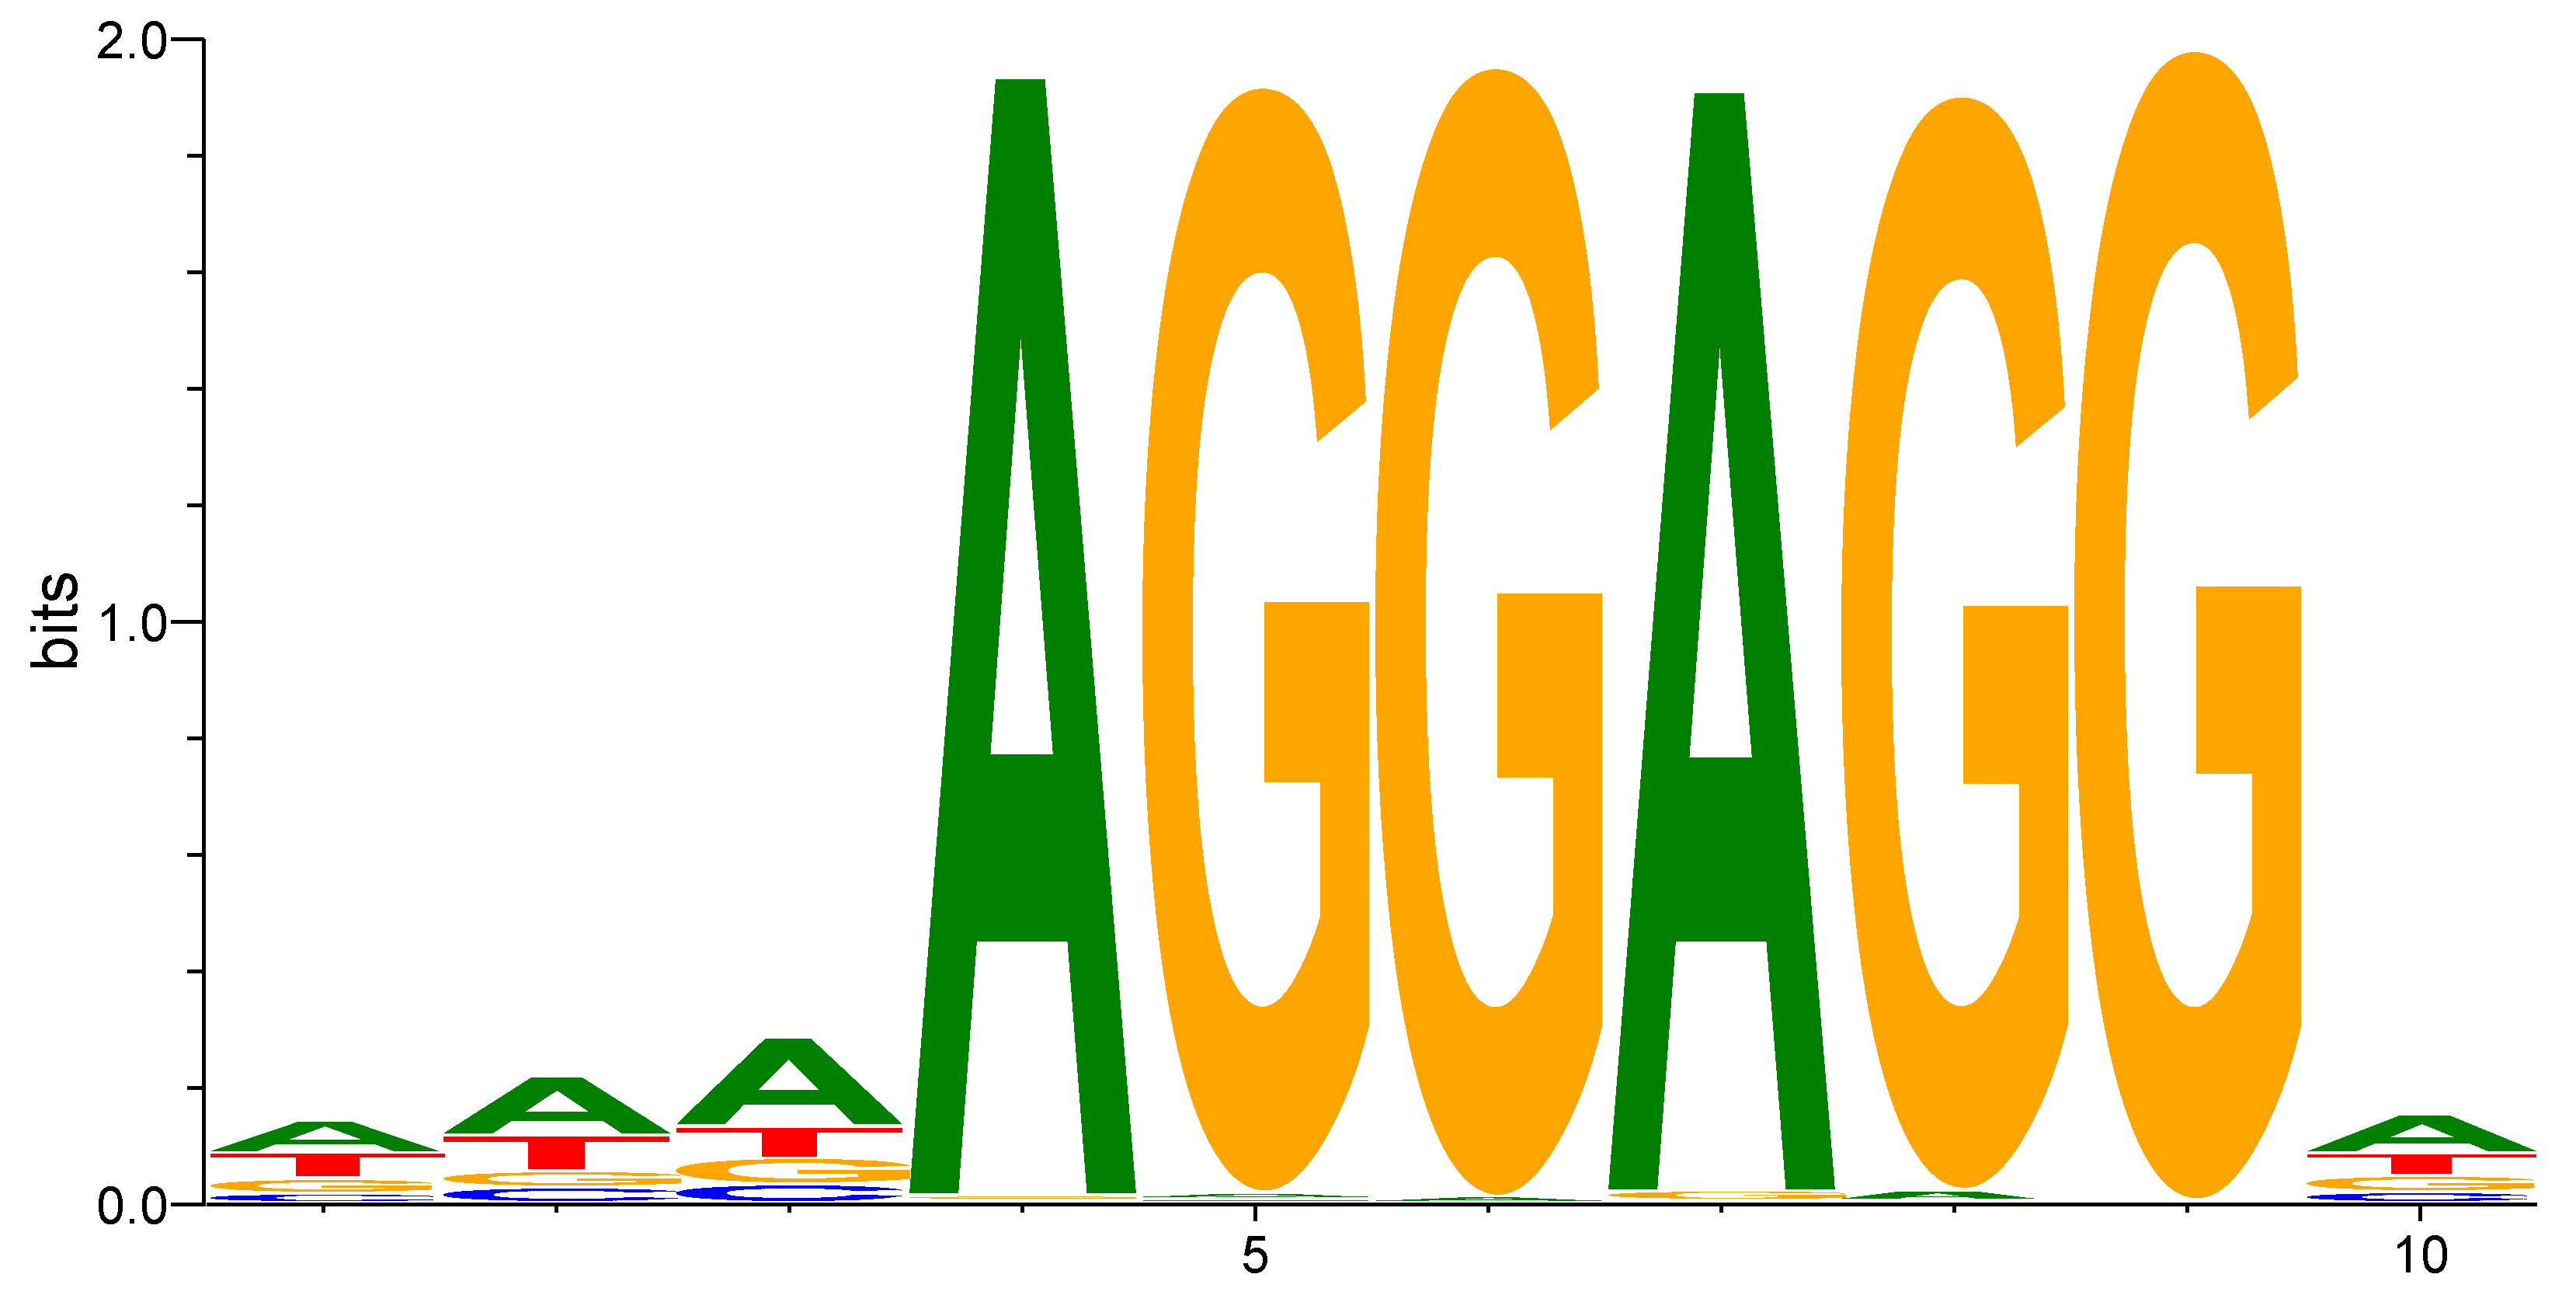

In [46]:
# Plot the final pfm that is generated: 
seqlogo.seqlogo(seqlogo.CompletePm(pfm = promoter_pfm.T))

---
# NRF1 Driver Program
Modify the code below and test your Gibbs Sampler.

In [47]:
# Here we test your Gibbs sampler.
# You do not need to edit this or the section below. This is the Driver program

'''
Pseudocode: 
nrf1_file="<path/to/file.fa>"
nrf1_peaks = []

FOR name, seq in get_fasta(nrf1_file):
nrf1_peaks.append(seq)
'''

#read promoters, store in a list of strings
nrf1_file = "data/nrf1_gibbs.fa"

nrf1_peaks = []

for name, seq in get_fasta(nrf1_file):
    nrf1_peaks.append(seq)


# Run the gibbs sampler:
nrf1_pfm = GibbsMotifFinder(nrf1_peaks, 10)



--- Iteration 500 / 10,000 ---
Held-out sequence: 34792
Chosen position: 63
Current motif: GGGCCTCCTG
Current IC: 0.1333
Best IC: 0.1333
Elapsed time: 5.16 minutes
Estimated remaining time: 97.96 minutes

--- Iteration 1,000 / 10,000 ---
Held-out sequence: 8415
Chosen position: 46
Current motif: GTCCAGCCGG
Current IC: 0.1346
Best IC: 0.1346
Elapsed time: 10.31 minutes
Estimated remaining time: 92.79 minutes

--- Iteration 1,500 / 10,000 ---
Held-out sequence: 51589
Chosen position: 41
Current motif: AGACTGTCCC
Current IC: 0.1357
Best IC: 0.1358
Elapsed time: 15.41 minutes
Estimated remaining time: 87.33 minutes

--- Iteration 2,000 / 10,000 ---
Held-out sequence: 75247
Chosen position: 2
Current motif: GGCAGGTGAG
Current IC: 0.1370
Best IC: 0.1370
Elapsed time: 20.40 minutes
Estimated remaining time: 81.61 minutes

--- Iteration 2,500 / 10,000 ---
Held-out sequence: 43883
Chosen position: 8
Current motif: GGGGTGGCAG
Current IC: 0.1384
Best IC: 0.1384
Elapsed time: 25.40 minutes
Estimat

In [48]:
promoter_freq = (nrf1_pfm /nrf1_pfm.sum(axis=0, keepdims=True))

bases = np.array(["A", "C", "G", "T"])
consensus = "".join(bases[np.argmax(promoter_freq, axis=0)])

print("Consensus:", consensus)

Consensus: GGGCGGCGGG


In [49]:
print(promoter_freq)

[[0.22813426 0.21667536 0.21207848 0.21547618 0.22091693 0.21417706
  0.21196744 0.21381064 0.2220606  0.21352195]
 [0.26552004 0.27669024 0.28603946 0.28927061 0.27976594 0.28921509
  0.29145801 0.28009904 0.27157149 0.27711218]
 [0.29292369 0.30128468 0.28852667 0.27916634 0.28744962 0.29311245
  0.28147589 0.29146912 0.29686546 0.30930147]
 [0.21342201 0.20534971 0.21335539 0.21608687 0.21186751 0.20349541
  0.21509866 0.2146212  0.20950245 0.2000644 ]]


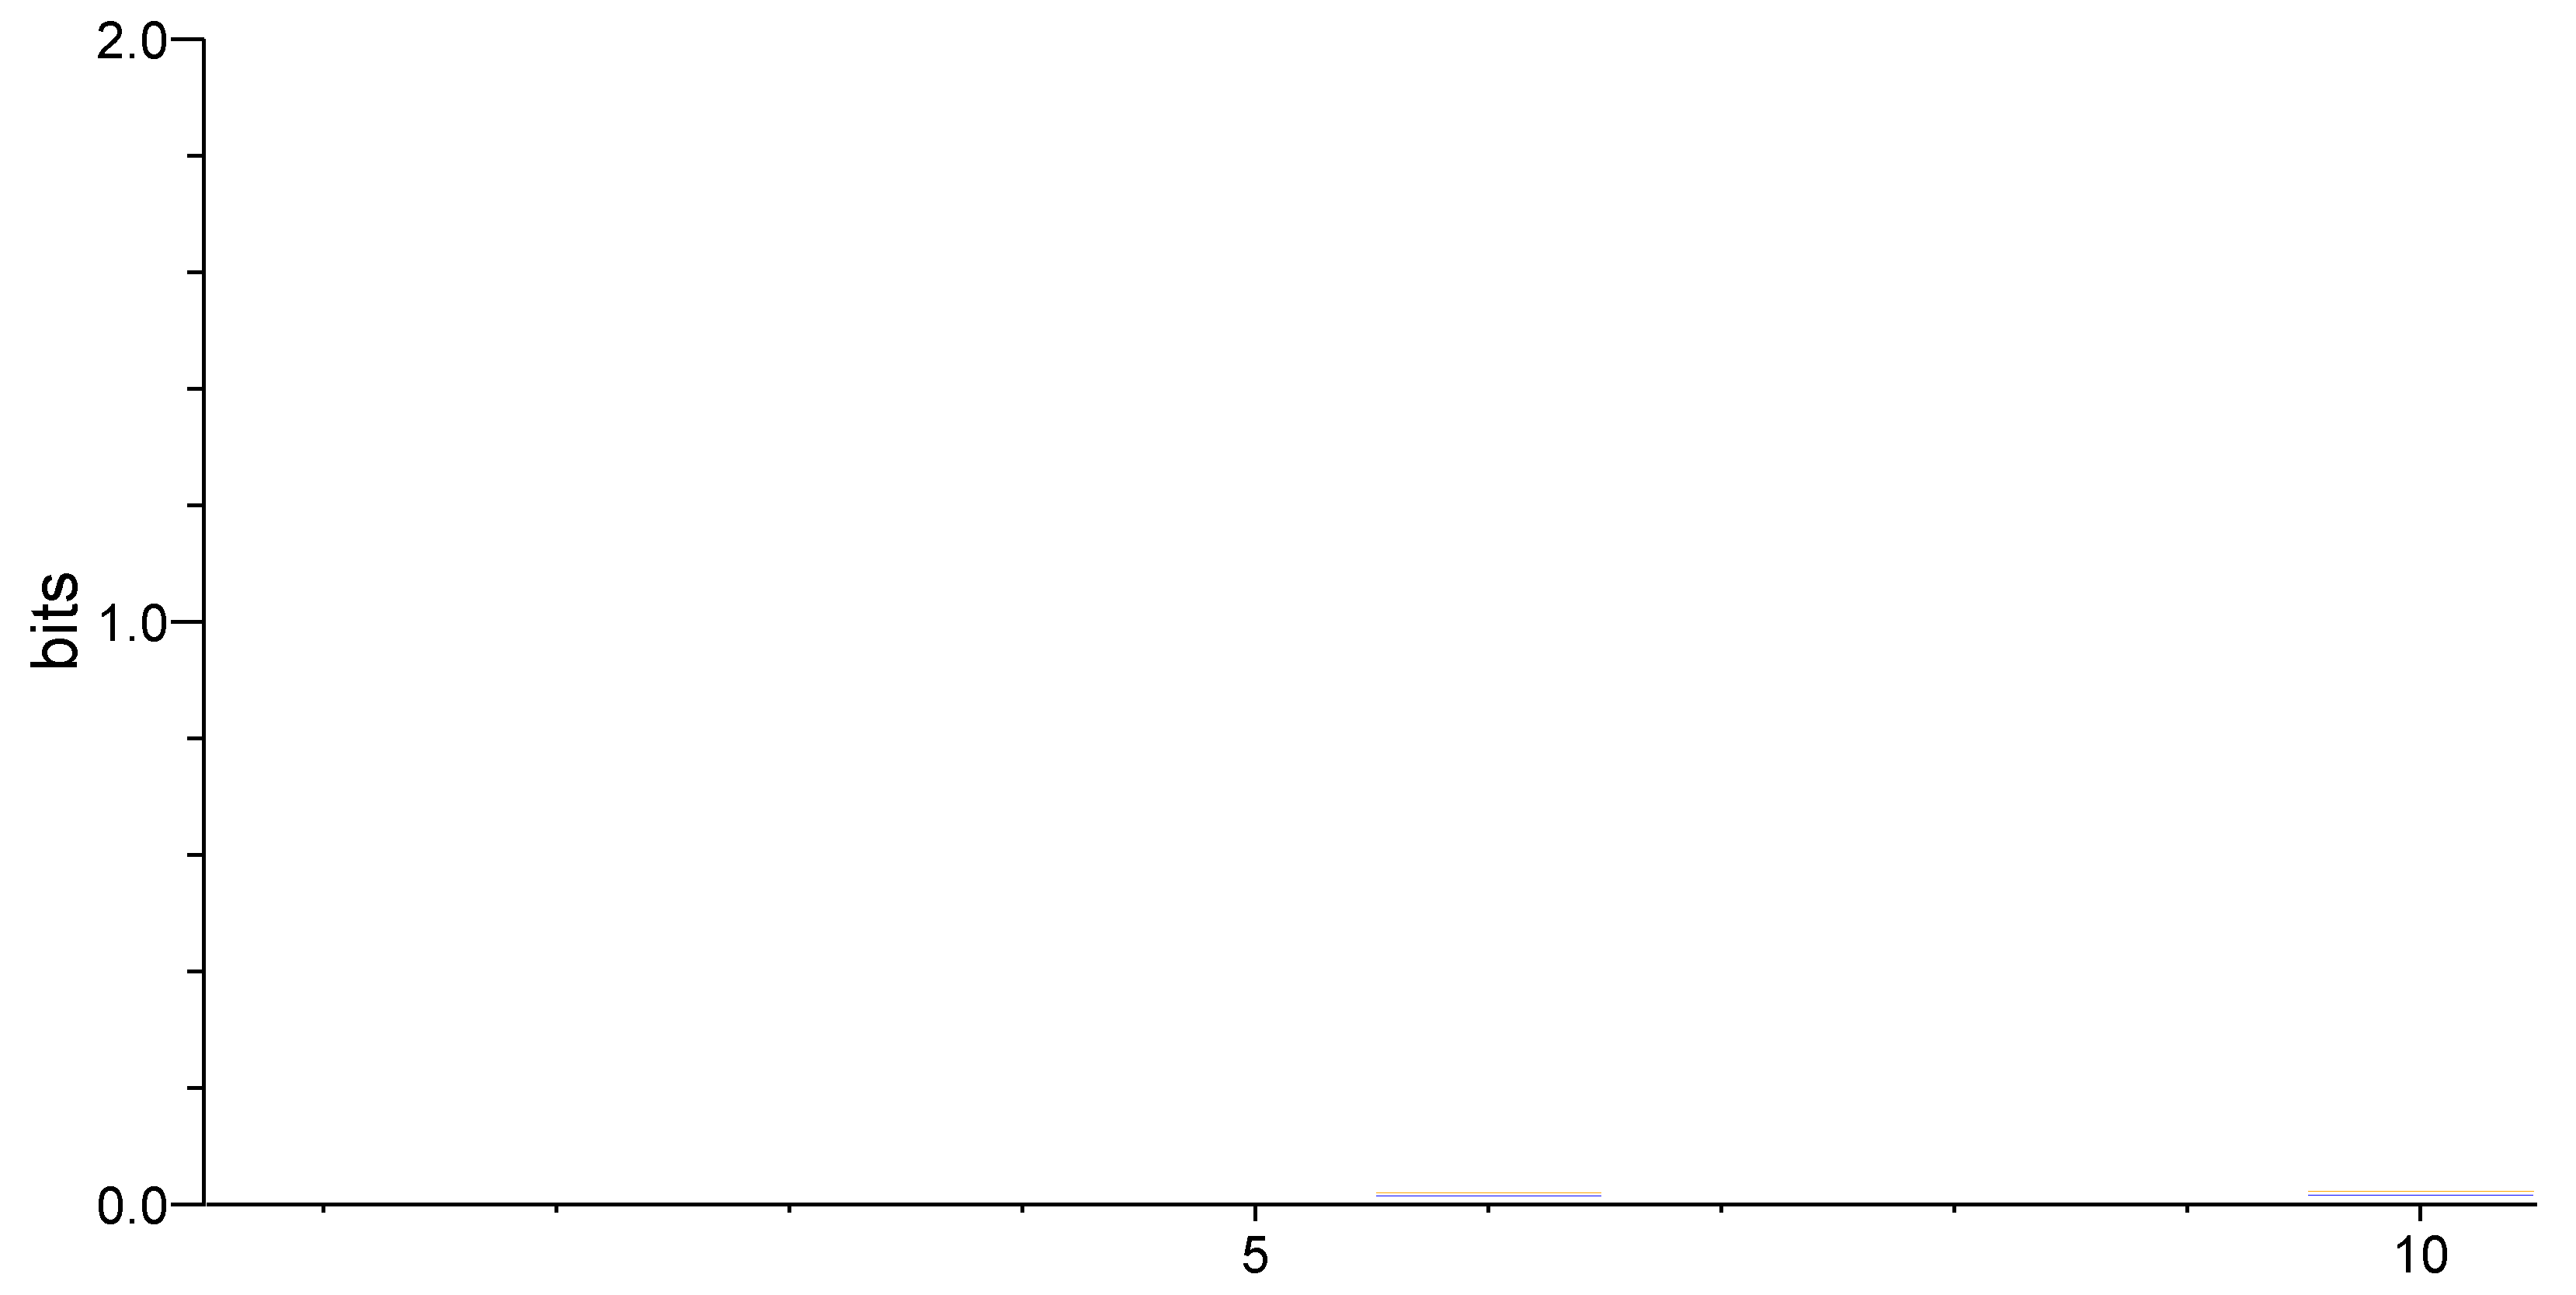

In [51]:
# Plot the final pfm that is generated: 
seqlogo.seqlogo(seqlogo.CompletePm(pfm = promoter_freq.T)) #Note: comment out to remove empty graph because of GhostScript

#sanity check our results without in case seqlogo in NRF1 Driver Program doesn't work
#Note: NRF1 has ~90,000 sequences (versus ~800 for promoters), so it will take a long time to run 10,000 rounds.  
#A quick 100 round test showed working code but a low IC score, which is expected for just a few rounds
#print(nrf1_pfm)
#print(pfm_ic(nrf1_pfm))

This was the close we were able to get to visualize the output.

Consensus: GGGCGGCGGG


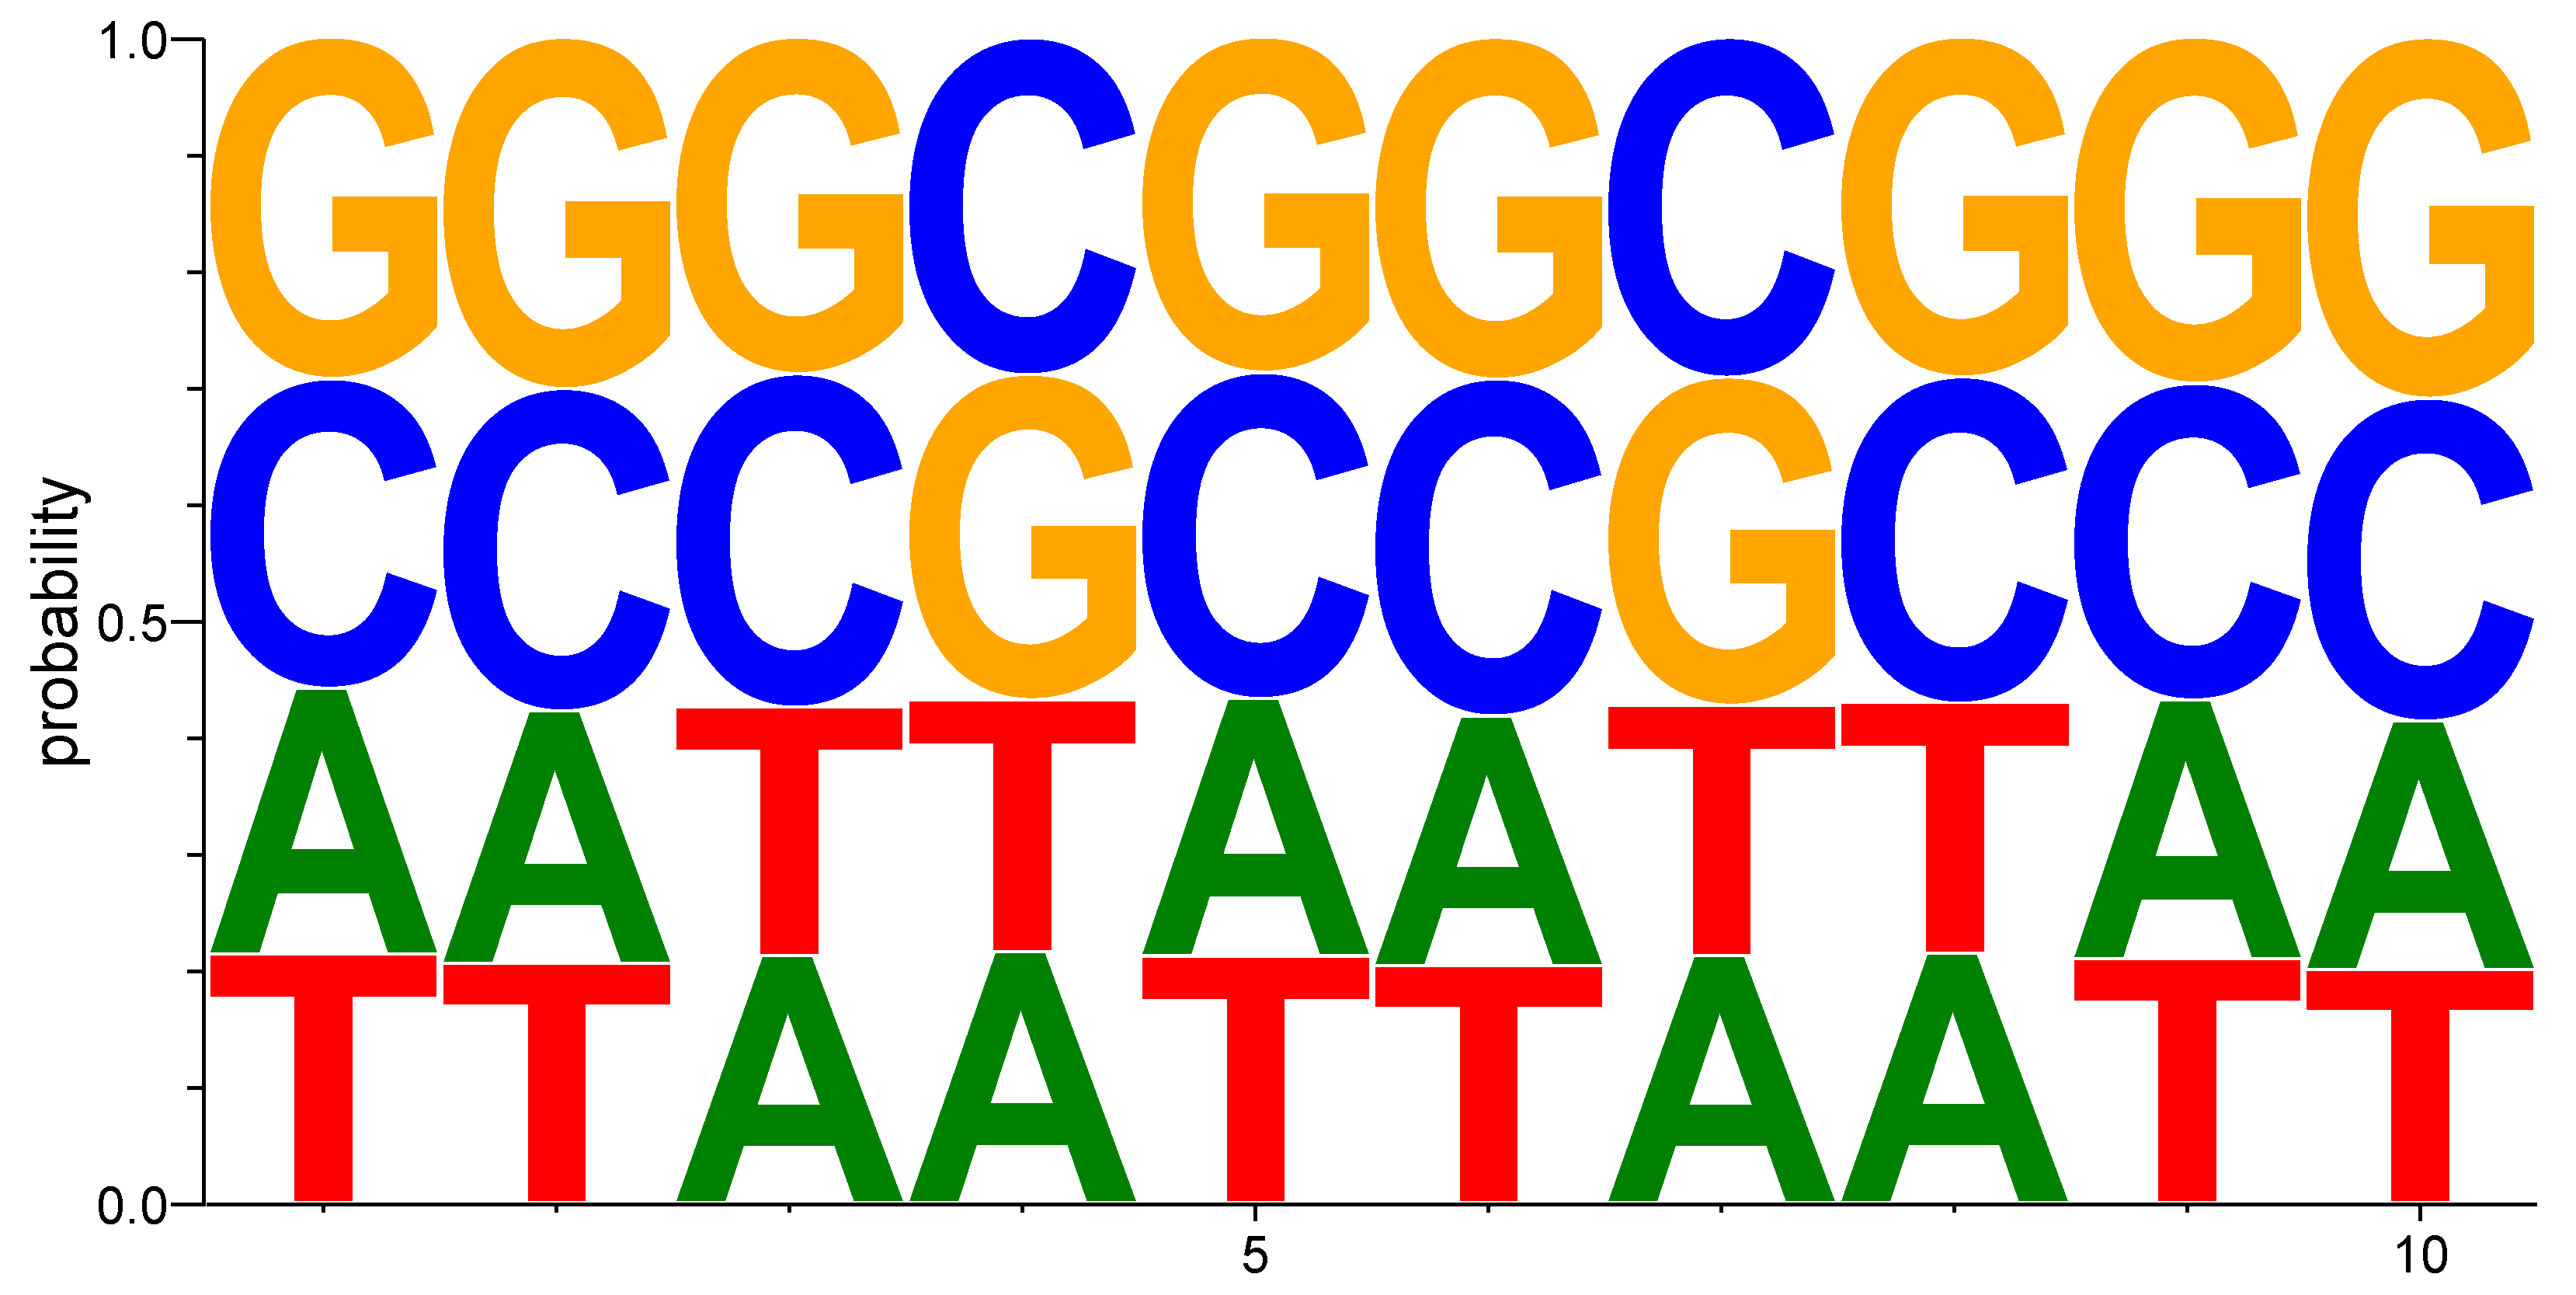

In [56]:
bases = np.array(["A", "C", "G", "T"])
consensus = "".join(bases[np.argmax(promoter_freq, axis=0)])

print("Consensus:", consensus)

seqlogo.seqlogo(
    seqlogo.CompletePm(pfm=promoter_freq.T),
    ic_scale=False
)